<a href="https://colab.research.google.com/github/Gitjimii/Suji-Official-repo/blob/main/YOLOV8_TRAIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics roboflow

In [ ]:
#Download dataset 1
from roboflow import Roboflow
rf = Roboflow(api_key="7FRy7Sks4UJTwnMf828D")
project1 = rf.workspace("material-identification").project("garbage-classification-3")
dataset1 = project1.version(2).download("yolov8")
# Download Dataset 2
project2 = rf.workspace("garbage-detection-czeg5").project("garbage_detection-wvzwv")
dataset2 = project2.version(18).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to GARBAGE-CLASSIFICATION-3-2 in yolov8:: 100%|██████████| 20940/20940 [00:02<00:00, 8282.95it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to garbage_detection-18 in yolov8:: 100%|██████████| 8386/8386 [00:01<00:00, 4629.88it/s]


In [ ]:
# Check Dataset 1 structure
!ls {dataset1.location}

# Check Dataset 2 structure
!ls {dataset2.location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")  # You can choose other variants like yolov8s, yolov8m, etc.

# Train the model on Dataset 2
results = model.train(data=f"{dataset2.location}/data.yaml", epochs=100, imgsz=640, batch=16)

100%|██████████| 6.25M/6.25M [00:00<00:00, 108MB/s]


Ultralytics 8.3.75 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/garbage_detection-18/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tr

100%|██████████| 755k/755k [00:00<00:00, 19.4MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 117MB/s]


...

    100/100      2.19G     0.6287     0.4419      1.311          5        640: 100%|██████████| 230/230 [01:02<00:00,  3.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  4.09it/s]

                   all        260        271      0.898      0.813      0.863      0.551



100 epochs completed in 1.923 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.75 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.27it/s]


                   all        260        271      0.899      0.827      0.884      0.572
Speed: 0.2ms preprocess, 2.6ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/detect/train


In [ ]:
!pip install --no-cache-dir onnx2tf sng4onnx onnx_graphsurgeon onnx onnxslim tflite_support protobuf


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.5/147.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.2/446.2 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 287.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 284.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 344.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 MB 181.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 349.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 kB 353.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.6
    Uninstalling protobuf-4.25.6:
      Successfully uninstalled protobuf-4.25.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Save the model weights to Google Drive
!cp runs/detect/train/weights/best.pt /content/drive/MyDrive/


Mounted at /content/drive
cp: cannot stat 'runs/detect/train/weights/best.pt': No such file or directory


In [5]:
!ls /content/drive/MyDrive/


'AI ALL DETAILS DAY 1 BONUS.docx'  'Colab Notebooks'	     'SUJI IMP DOCUMENTS'
 best.pt			   'INTERVIEW CHEAT SHEETS'  'SUJITHA_RESUME .pdf'
'CAP PYTHON FILES'		    Pass


In [6]:
from ultralytics import YOLO

# Load the model
model = YOLO('/content/drive/MyDrive/best.pt')  # Ensure this path is correct


In [7]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/drive/MyDrive/best.pt")

print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
from google.colab import files

# Upload an image
uploaded = files.upload()


Saving 07ff75e6-6799-11e5-8dd0-40f2e96c8ad8_jpg.rf.6e2fc221cd02c7e37fec6ca9af25d9f5.jpg to 07ff75e6-6799-11e5-8dd0-40f2e96c8ad8_jpg.rf.6e2fc221cd02c7e37fec6ca9af25d9f5.jpg


In [ ]:
import os

image_path = "/content/07ff75e6-6799-11e5-8dd0-40f2e96c8ad8_jpg.rf.6e2fc221cd02c7e37fec6ca9af25d9f5.jpg"
print("Exists:", os.path.exists(image_path))  # Should print: True


Exists: True


In [ ]:
results = model(image_path, conf=0.25, save=True)



image 1/1 /content/07ff75e6-6799-11e5-8dd0-40f2e96c8ad8_jpg.rf.6e2fc221cd02c7e37fec6ca9af25d9f5.jpg: 640x640 1 garbage, 15.0ms
Speed: 3.9ms preprocess, 15.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2


In [ ]:
import os

dataset_path = dataset2.location  # Update if needed

for folder in ["train", "valid"]:
    images_path = os.path.join(dataset_path, folder, "images")  # Check 'images' subfolder
    if os.path.exists(images_path):
        images = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        print(f"{folder}/images contains {len(images)} images")
    else:
        print(f"{folder}/images folder not found!")


train/images contains 3669 images
valid/images contains 260 images


In [ ]:
!ls /content/garbage_detection-18/train
!ls /content/garbage_detection-18/valid


images	labels
images	labels


In [ ]:
import os

# Define paths
train_folder = "/content/garbage_detection-18/train/images"
valid_folder = "/content/garbage_detection-18/valid/images"

# Check if paths exist and list images
if os.path.exists(train_folder):
    print("Train Images:", os.listdir(train_folder)[:5])
else:
    print("Train folder not found!")

if os.path.exists(valid_folder):
    print("Valid Images:", os.listdir(valid_folder)[:5])
else:
    print("Valid folder not found!")


Train Images: ['55545fa2-679c-11e5-aa4a-40f2e96c8ad8_jpg.rf.1f9dddd731b71be59d72e1d25d9384f5.jpg', 'images45_jpg.rf.8b7c92c6d0734425b7020fea5a975c9e.jpg', 'piles-of-garbage-and-the-trash-picture-id495976846_jpg.rf.7524cbffc31290eadca54ce528dc6e64.jpg', 'Sampah_di_simpang_Jalan_Gabus_dan_Jalan_Tuanku_Tambusai_Pekanbaru_Riau2-JPG_jpg.rf.2d65a68fc18b8cd32ee8af2288bbd0ef.jpg', 'image27_jpeg.rf.46285d8e91d419f7ff5778709685c789.jpg']
Valid Images: ['marseille-letat-tape-du-poing-face-aux-ordures-envahissant-les-rues_jpg.rf.12a11c3a3ca8914d8391ddca1db7631a.jpg', 'palermo4_jpg.rf.b2ab78192a0fbb638e23c9e3e85b3e62.jpg', 'trash-picture-id527569195_jpg.rf.f57226ae3dcb0a4b8e031e2c94dafa49.jpg', 'recycle-bins-picture-id625417110_jpg.rf.46f64ce7a83ce923af7877b4473f05a1.jpg', 'depositphotos_520804268-stock-photo-photo-large-amount-waste-paper3_jpg.rf.74fad9d468d5c0a6f62fbfbdca679235.jpg']


In [ ]:
test_images = [
    "/content/garbage_detection-18/train/images/55545fa2-679c-11e5-aa4a-40f2e96c8ad8_jpg.rf.1f9dddd731b71be59d72e1d25d9384f5.jpg",
    "/content/garbage_detection-18/train/images/images45_jpg.rf.8b7c92c6d0734425b7020fea5a975c9e.jpg",
    "/content/garbage_detection-18/train/images/piles-of-garbage-and-the-trash-picture-id495976846_jpg.rf.7524cbffc31290eadca54ce528dc6e64.jpg",
    "/content/garbage_detection-18/valid/images/marseille-letat-tape-du-poing-face-aux-ordures-envahissant-les-rues_jpg.rf.12a11c3a3ca8914d8391ddca1db7631a.jpg",
    "/content/garbage_detection-18/valid/images/trash-picture-id527569195_jpg.rf.f57226ae3dcb0a4b8e031e2c94dafa49.jpg"
]

for img_path in test_images:
    results = model(img_path, conf=0.25, save=True)
    print(results)



image 1/1 /content/garbage_detection-18/train/images/55545fa2-679c-11e5-aa4a-40f2e96c8ad8_jpg.rf.1f9dddd731b71be59d72e1d25d9384f5.jpg: 640x640 1 garbage, 11.5ms
Speed: 2.8ms preprocess, 11.5ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'garbage'}
obb: None
orig_img: array([[[ 14,   1,   0],
        [ 14,   1,   0],
        [ 14,   1,   0],
        ...,
        [  0,   1,   1],
        [  0,   1,   1],
        [  0,   1,   1]],

       [[206, 193, 185],
        [206, 193, 185],
        [206, 193, 185],
        ...,
        [219, 227, 227],
        [219, 227, 227],
        [219, 227, 227]],

       [[212, 196, 189],
        [212, 196, 189],
        [213, 197, 190],
        ...,
        [211, 222, 220],
        [213, 221, 220],
        [213, 221, 220]],

       ...,

       [[179, 162


image 1/1 /content/garbage_detection-18/train/images/55545fa2-679c-11e5-aa4a-40f2e96c8ad8_jpg.rf.1f9dddd731b71be59d72e1d25d9384f5.jpg: 640x640 1 garbage, 10.3ms
Speed: 2.7ms preprocess, 10.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2

image 1/1 /content/garbage_detection-18/train/images/images45_jpg.rf.8b7c92c6d0734425b7020fea5a975c9e.jpg: 640x640 1 garbage, 7.2ms
Speed: 2.3ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2

image 1/1 /content/garbage_detection-18/train/images/piles-of-garbage-and-the-trash-picture-id495976846_jpg.rf.7524cbffc31290eadca54ce528dc6e64.jpg: 640x640 1 garbage, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2

image 1/1 /content/garbage_detection-18/valid/images/marseille-letat-tape-du-poing-face-aux-ordures-envahissant-les-rues_jpg.r

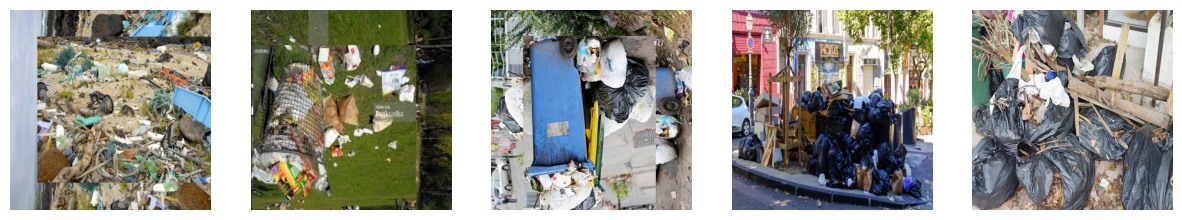

In [ ]:
import matplotlib.pyplot as plt
import cv2

test_images = [
    "/content/garbage_detection-18/train/images/55545fa2-679c-11e5-aa4a-40f2e96c8ad8_jpg.rf.1f9dddd731b71be59d72e1d25d9384f5.jpg",
    "/content/garbage_detection-18/train/images/images45_jpg.rf.8b7c92c6d0734425b7020fea5a975c9e.jpg",
    "/content/garbage_detection-18/train/images/piles-of-garbage-and-the-trash-picture-id495976846_jpg.rf.7524cbffc31290eadca54ce528dc6e64.jpg",
    "/content/garbage_detection-18/valid/images/marseille-letat-tape-du-poing-face-aux-ordures-envahissant-les-rues_jpg.rf.12a11c3a3ca8914d8391ddca1db7631a.jpg",
    "/content/garbage_detection-18/valid/images/trash-picture-id527569195_jpg.rf.f57226ae3dcb0a4b8e031e2c94dafa49.jpg"
]

# Run detection and save results
for img_path in test_images:
    results = model(img_path, conf=0.25, save=True)

# Display the images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, img_path in enumerate(test_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].axis("off")

plt.show()


Saving plastic1164_jpg.rf.72a67cb87c6ad88c662b51aa7d650e61.jpg to plastic1164_jpg.rf.72a67cb87c6ad88c662b51aa7d650e61.jpg

image 1/1 /content/plastic1164_jpg.rf.72a67cb87c6ad88c662b51aa7d650e61.jpg: 640x640 2 garbages, 10.7ms
Speed: 3.2ms preprocess, 10.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


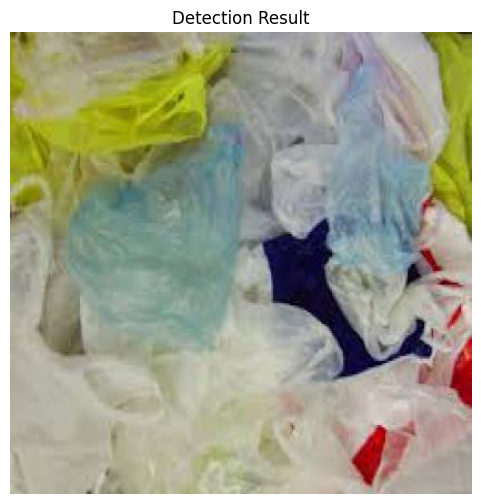

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()


Saving plastic751_jpg.rf.1d734b63cb62ec1162b35f7d71ca2e49.jpg to plastic751_jpg.rf.1d734b63cb62ec1162b35f7d71ca2e49.jpg

image 1/1 /content/plastic751_jpg.rf.1d734b63cb62ec1162b35f7d71ca2e49.jpg: 640x640 1 garbage, 10.1ms
Speed: 3.6ms preprocess, 10.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


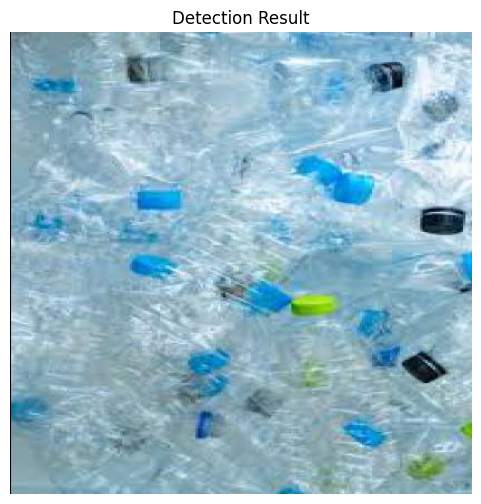

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()


Saving paper999_jpg.rf.240d6383d4f6cc0bb56b171f4277aa64.jpg to paper999_jpg.rf.240d6383d4f6cc0bb56b171f4277aa64.jpg

image 1/1 /content/paper999_jpg.rf.240d6383d4f6cc0bb56b171f4277aa64.jpg: 640x640 1 garbage, 9.7ms
Speed: 3.1ms preprocess, 9.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


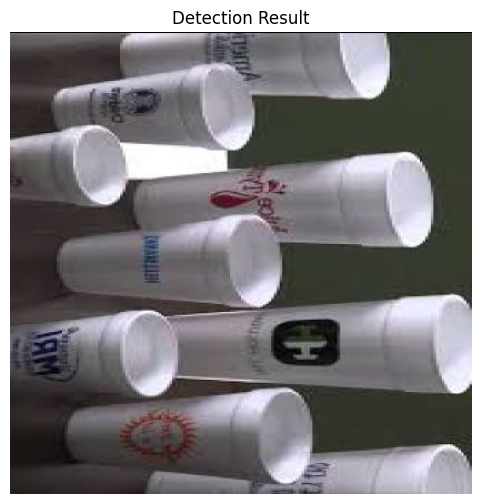

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()


Saving plastic591_jpg.rf.caab63a9fbe4b187b87fb3d7f5a0b4d0.jpg to plastic591_jpg.rf.caab63a9fbe4b187b87fb3d7f5a0b4d0.jpg

image 1/1 /content/plastic591_jpg.rf.caab63a9fbe4b187b87fb3d7f5a0b4d0.jpg: 640x640 2 garbages, 9.4ms
Speed: 3.9ms preprocess, 9.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


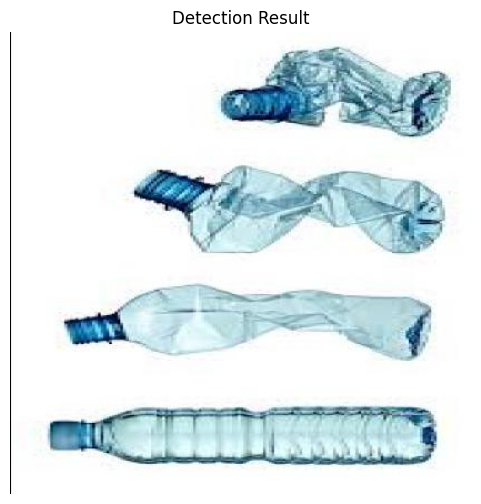

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()


Saving floatbot.png to floatbot.png

image 1/1 /content/floatbot.png: 448x640 2 garbages, 36.0ms
Speed: 2.7ms preprocess, 36.0ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


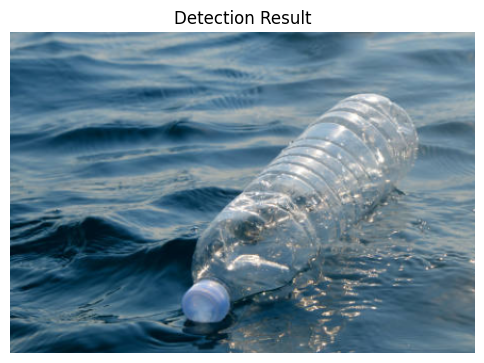

In [30]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

#own image detected

Saving eg9.png to eg9 (1).png

image 1/1 /content/eg9 (1).png: 352x640 1 garbage, 37.4ms
Speed: 2.5ms preprocess, 37.4ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)


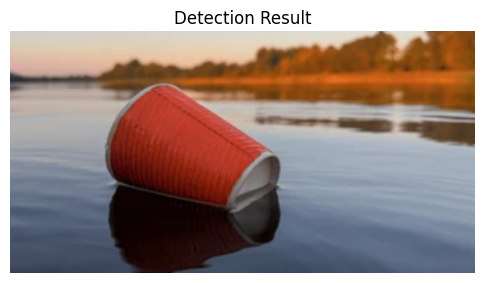

In [40]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving eg11.png to eg11 (1).png

image 1/1 /content/eg11 (1).png: 352x640 1 garbage, 11.8ms
Speed: 2.5ms preprocess, 11.8ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)


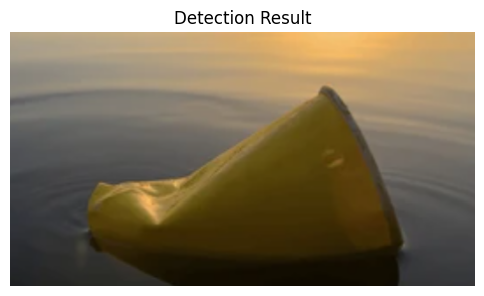

In [45]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving eg4.png to eg4 (1).png

image 1/1 /content/eg4 (1).png: 448x640 1 garbage, 7.8ms
Speed: 2.0ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


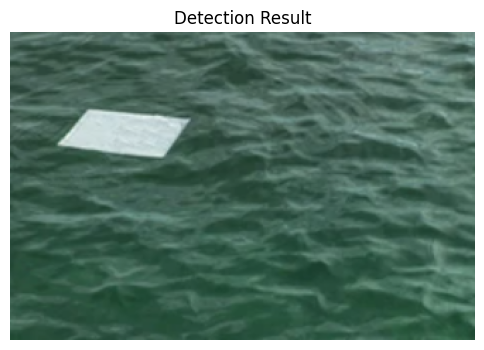

In [46]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving eg6.png to eg6 (1).png

image 1/1 /content/eg6 (1).png: 448x640 1 garbage, 7.2ms
Speed: 2.5ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


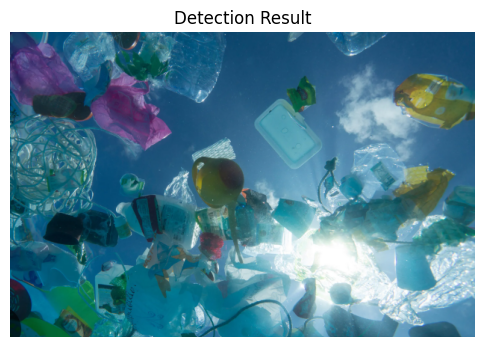

In [47]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving biodegradable1_jpg.rf.4c70316c07a30a7aafbe72b6ba1bb21a.jpg to biodegradable1_jpg.rf.4c70316c07a30a7aafbe72b6ba1bb21a.jpg

image 1/1 /content/biodegradable1_jpg.rf.4c70316c07a30a7aafbe72b6ba1bb21a.jpg: 640x640 (no detections), 8.8ms
Speed: 3.5ms preprocess, 8.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


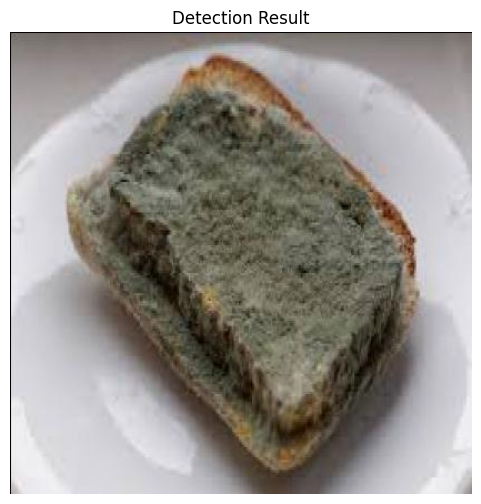

In [50]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving cardboard324_jpg.rf.c962e6339aaaf8d5492e01fb614c27e9.jpg to cardboard324_jpg.rf.c962e6339aaaf8d5492e01fb614c27e9.jpg

image 1/1 /content/cardboard324_jpg.rf.c962e6339aaaf8d5492e01fb614c27e9.jpg: 640x640 2 garbages, 18.4ms
Speed: 4.3ms preprocess, 18.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


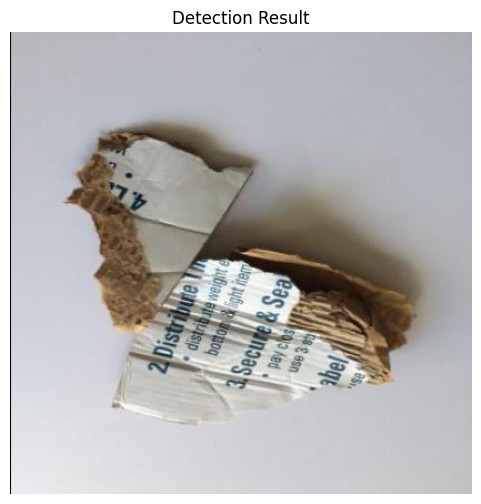

In [57]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving eg14.png to eg14.png

image 1/1 /content/eg14.png: 384x640 1 garbage, 15.1ms
Speed: 3.0ms preprocess, 15.1ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)


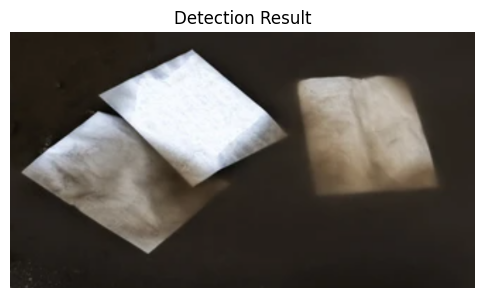

In [58]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()

Saving metal6_jpg.rf.69cdb75a214ab6fbfba9fe3e7ed8469c.jpg to metal6_jpg.rf.69cdb75a214ab6fbfba9fe3e7ed8469c.jpg

image 1/1 /content/metal6_jpg.rf.69cdb75a214ab6fbfba9fe3e7ed8469c.jpg: 640x640 1 garbage, 11.2ms
Speed: 4.1ms preprocess, 11.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


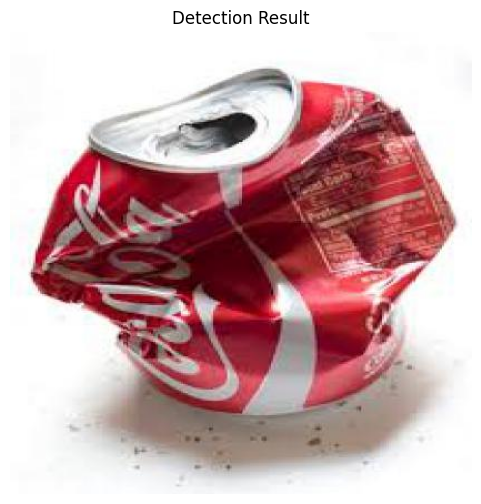

In [59]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded file name

# Run detection
results = model(image_path, conf=0.1)

# Load and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Detection Result")
plt.axis("off")
plt.show()